In [1]:
!pip install tensorflow
!pip install scikit-learn
!pip install matplotlib
!pip install keras
!pip install keras_tuner
!pip install gzip
!pip install numpy
!pip install ViennaRNA
!pip install regex
!pip install seaborn
!pip install tensorboard

ERROR: Could not find a version that satisfies the requirement gzip (from versions: none)


ERROR: No matching distribution found for gzip


In [2]:
import gzip
import pandas as pd
import numpy as np
import sklearn
import regex as re
import seaborn as sns
import keras as ks
import keras_tuner as kt
import csv
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.metrics import Precision, Recall, F1Score
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

I0000 00:00:1780497882.820017  575330 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780497882.828024  575330 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780497882.897569  575330 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1780497889.939521  575330 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780497889.943360  575330 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
simple_hairpin = ["","...(((...)))...",
"...((((...))))...",
"...(((((...)))))...",
"...((((((...))))))...",
"...(((((((....)))))))...",
"...((((((((....))))))))...",
"...(((((((((....)))))))))...",
"...((((((((((.....))))))))))...",
"...(((((((((((.......)))))))))))...",
"...((((((((((((........))))))))))))...",
"...(((((((((((((........)))))))))))))...",
"...((((((((((((((........))))))))))))))..."]

simple_bulgeloop = ["","...((..(...)))...",
"...((..((...))))...",
"...(((..((...)))))...",
"...(((..(((...))))))...",
"...((((...(((....)))))))...",
"...((((...((((....))))))))...",
"...(((((...((((....)))))))))...",
"...(((((....(((((.....))))))))))...",
"...((((((.....(((((.......)))))))))))...",
"...((((((......((((((........))))))))))))...",
"...(((((((......((((((........)))))))))))))...",
"...(((((((......(((((((........))))))))))))))..."]

repetitive_short_hairpins = ["","...(((...)))...",
"...(((...)))...(((...)))...",
"...(((...)))...(((...)))...(((...)))...",
"...(((...)))...(((...)))...(((...)))...(((...)))...",
"...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...",
"...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...",
"...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...",
"...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...",
"...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...",
"...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...",
"...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...",
"...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))..."]



In [4]:
chars = [".", ")", "("]

def insert_motif(background, motif):
    x = list(background)
    motif_len = len(motif)

    idx = np.random.randint(0, len(x) - motif_len + 1)

    x[idx:idx + motif_len] = list(motif)

    return "".join(x), idx

def shuffle_sequence(seq):
    chars = list(seq)
    np.random.shuffle(chars)
    return "".join(chars)
data_M1 = []

for _ in range(1000):
    seq = "".join(np.random.choice(chars, size=500, replace=True))
    data_M1.append(seq)
    

In [5]:
n_per_motif = 10000

n_total_positive = len(simple_hairpin) * n_per_motif

# M1: 1000 negatives
data_M1 = []

for _ in range(n_total_positive):
    seq = "".join(np.random.choice(chars, size=500, replace=True))
    data_M1.append(seq)

M1 = pd.DataFrame(data_M1, columns=["sequence"])
M1["label"] = 0

M2_base = M1.copy()
M2_base["sequence"] = M2_base["sequence"].apply(shuffle_sequence)

new_sequences = []
motifs = []
motif_starts = []

row_idx = 0

for motif in simple_hairpin:
    for _ in range(n_per_motif):
        background = M2_base.iloc[row_idx]["sequence"]

        new_seq, idx = insert_motif(background, motif)

        new_sequences.append(new_seq)
        motifs.append(motif)
        motif_starts.append(idx)

        row_idx += 1

M2 = pd.DataFrame({
    "sequence": new_sequences,
    "label": 1,
    "motif": motifs,
    "motif_start": motif_starts
})

M = pd.concat([M1, M2], ignore_index=True)

print(M["label"].value_counts())
print(M2["motif"].value_counts())
print(M[1000:])

label
0    130000
1    130000
Name: count, dtype: int64
motif
                                              10000
...(((...)))...                               10000
...((((...))))...                             10000
...(((((...)))))...                           10000
...((((((...))))))...                         10000
...(((((((....)))))))...                      10000
...((((((((....))))))))...                    10000
...(((((((((....)))))))))...                  10000
...((((((((((.....))))))))))...               10000
...(((((((((((.......)))))))))))...           10000
...((((((((((((........))))))))))))...        10000
...(((((((((((((........)))))))))))))...      10000
...((((((((((((((........))))))))))))))...    10000
Name: count, dtype: int64
                                                 sequence  label  \
1000    ().).(().)()()(.(())((..().(....)(.))..(..)(()...      0   
1001    )).))(....().(((..((()(.(()(.)))...)()(((.()()...      0   
1002    .))(.((())((.((()()..))(

In [6]:
def one_hot_encode(seq, fixlength=500):
    if len(seq) < fixlength:
        seq += "." * (fixlength - len(seq))

    seq = seq[:fixlength]

    mapping = {
        "(": [1, 0, 0],
        ".": [0, 1, 0],
        ")": [0, 0, 1]
    }

    return np.array([mapping[base] for base in seq])

In [7]:
# def stem_length(structure):
#     return structure.count("(")

# def paired_length(structure):
#     return min(structure.count("("),structure.count(")"))

# def loop_length(structure):
#     loops = re.findall(r"\.+", structure)
#     if loops:
#         return max(len(loop) for loop in loops)
#     return 0

# def paired_ratio(structure):
#     paired = structure.count("(") + structure.count(")")
#     return paired / len(structure)

# def max_depth(structure):
#     depth = 0
#     max_d = 0

#     for char in structure:

#         if char == "(":
#             depth += 1
#             max_d = max(max_d, depth)

#         elif char == ")":
#             depth -= 1

#     return max_d

# def bulge_count(structure):
#     return structure.count("..")

# def stem_count(structure):
#     stems = re.findall(r"\(+", structure)
#     return len(stems)



In [8]:
def stem_length(structure):
    return structure.count("(")

def paired_length(structure):
    return min(structure.count("("),structure.count(")"))

def loop_length(structure):
    loops = re.findall(r"\.+", structure)
    if loops:
        return max(len(loop) for loop in loops)
    return 0

def paired_ratio(structure):
    paired = structure.count("(") + structure.count(")")
    return paired / len(structure)

def max_depth(structure):
    depth = 0
    max_d = 0

    for char in structure:

        if char == "(":
            depth += 1
            max_d = max(max_d, depth)

        elif char == ")":
            depth -= 1

    return max_d

def bulge_count(structure):
    return structure.count("..")

def stem_count(structure):
    stems = re.findall(r"\(+", structure)
    return len(stems)

def repetitive_count(structure):
    unit = "(((...)))"
    return structure.count(unit)

In [9]:
def build_model(hp):
    model = Sequential([
        Conv1D(
            filters = hp.Choice("filter_1", [16, 32, 64, 128]),
            kernel_size = hp.Choice("kernel_1", [3, 5, 8, 12]),
            activation = 'relu',
            input_shape = (500,3)
        ),
        MaxPooling1D(
            pool_size = hp.Choice("pool_size_1", [2,3,4])        
        ),
        Conv1D(
            filters = hp.Choice("filter_2", [16, 32, 64, 128]),
            kernel_size = hp.Choice("kernel_2", [3, 5, 8, 12]),
            activation = 'relu'
        ),
        MaxPooling1D(
            pool_size = hp.Choice("pool_size_2", [2,3,4])        
        ),
        Flatten(),
        Dense(
            units = hp.Choice("units_1", [16, 32, 64, 128]),
            activation='relu'
        ),
        Dropout(
            rate = hp.Choice("rate", [0.3, 0.5])
        ),
        Dense(
            units = hp.Choice("units_2", [1]),
            activation='sigmoid'
        )
        
    ])
    
    model.compile(
        optimizer = Adam(
            learning_rate = hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])
        ),
        loss = 'binary_crossentropy',
        metrics=[
            'accuracy'
            
        ]
    )
    
    return model



In [10]:
def build_fixed_model():
    model = Sequential([
        Conv1D(32, kernel_size=8, activation="relu", input_shape=(500, 3)),
        MaxPooling1D(pool_size=2),

        Conv1D(64, kernel_size=8, activation="relu"),
        MaxPooling1D(pool_size=2),

        Flatten(),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [11]:
M["encoded_sequence"] = M["sequence"].apply(one_hot_encode, fixlength=500)

X = np.array(list(M["encoded_sequence"].values))
y = np.array(M["label"].values)

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=5,
    overwrite=True,
    directory="tuner_results",
    project_name="hairpin_global_tuning"
)

tuner.search(
    X_train_all,
    y_train_all,
    epochs=5,
    validation_split=0.2
)

best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best hyperparameters:")
print(best_hp.values)

Trial 5 Complete [00h 01m 22s]
val_loss: 0.15572011470794678

Best val_loss So Far: 0.14917078614234924
Total elapsed time: 00h 07m 14s
Best hyperparameters:
{'filter_1': 16, 'kernel_1': 3, 'pool_size_1': 3, 'filter_2': 64, 'kernel_2': 12, 'pool_size_2': 4, 'units_1': 16, 'rate': 0.3, 'units_2': 1, 'learning_rate': 0.0001}


In [12]:
model = build_model(best_hp)

In [13]:
results = []

for motif in simple_hairpin:
    for seed in range(3):
        M_pos = M[(M["label"] == 1) & (M["motif"] == motif)]

        M_neg = M[M["label"] == 0].sample(
            n=len(M_pos),
            random_state=seed
        )
        print("Motif:", motif)
        print("Positive contains motif:", M_pos["sequence"].str.contains(motif, regex=False).mean())
        print("Negative contains motif:", M_neg["sequence"].str.contains(motif, regex=False).mean())

        M_sub = pd.concat([M_neg, M_pos], ignore_index=False)
        M_sub["encoded_sequence"] = M_sub["sequence"].apply(one_hot_encode, fixlength=500)
        
        X = np.array(list(M_sub["encoded_sequence"].values))
        y = np.array(M_sub["label"].values)

        print(motif)
        print(M_sub["label"].value_counts())

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=seed,
            stratify=y
        )
        

        model = tuner.hypermodel.build(best_hp)


        model.fit(
            X_train,
            y_train,
            epochs=5,
            batch_size=32,
            validation_split=0.2,
            verbose=0
        )

        loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

        y_pred_prob = model.predict(X_test, verbose=0)
        y_pred = (y_pred_prob >= 0.5).astype(int).ravel()
            
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        results.append({
            "motif": motif,
            "seed": seed,
            "accuracy": accuracy,
            # "best_hp": best_hp.values,
            "paired_length": paired_length(motif),
            "sequence_length": len(motif),
            "precision": precision,
            "recall": recall,
            "F1 score": f1
        })

        print(f"\nMotif: {motif}")
        print(f"Accuracy: {accuracy}")
        print(f"paired_length: {paired_length(motif)}"),
        # print(f"Best hyperparameter values: {best_hp.values}")
        print(f"Precision: {precision}")
        print(f"Recall: {recall}"),
        print(f"F1-score: {f1}")
        
with open("cnn_testdata_output_hairpin_20k.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerows(results) 
        

Motif: 
Positive contains motif: 1.0
Negative contains motif: 1.0



label
0    10000
1    10000
Name: count, dtype: int64


/home/kelia/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Motif: 
Accuracy: 0.5
paired_length: 0
Precision: 0.0
Recall: 0.0
F1-score: 0.0
Motif: 
Positive contains motif: 1.0
Negative contains motif: 1.0



label
0    10000
1    10000
Name: count, dtype: int64


...

/home/kelia/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Motif: ...((((((((((((((........))))))))))))))...
Accuracy: 0.9990000128746033
paired_length: 14
Precision: 0.998003992015968
Recall: 1.0
F1-score: 0.999000999000999
Motif: ...((((((((((((((........))))))))))))))...
Positive contains motif: 1.0
Negative contains motif: 0.0


...((((((((((((((........))))))))))))))...
label
0    10000
1    10000
Name: count, dtype: int64


/home/kelia/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Motif: ...((((((((((((((........))))))))))))))...
Accuracy: 0.9994999766349792
paired_length: 14
Precision: 0.9995
Recall: 0.9995
F1-score: 0.9995


In [14]:
print(M_sub["label"].value_counts())

label
0    10000
1    10000
Name: count, dtype: int64


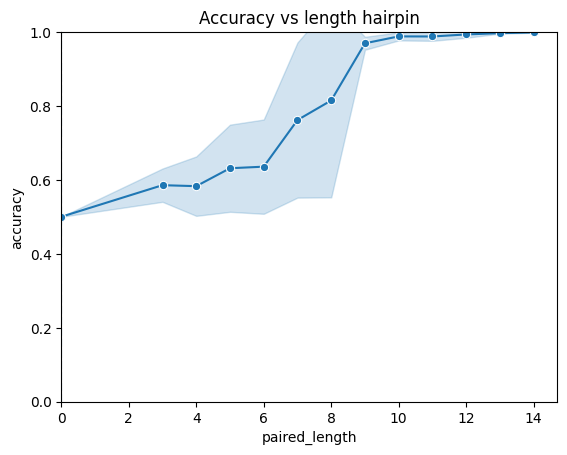

<Figure size 640x480 with 0 Axes>

In [15]:
results_df_hairpin = pd.DataFrame(results)

sns.lineplot(
    data=results_df_hairpin.sort_values("paired_length"),
    x="paired_length",
    y="accuracy",
    marker="o",
    errorbar="sd"
)

plt.axvline(x=0, linestyle="--")
plt.xlim(left=0)
plt.ylim(0,1)
plt.title("Accuracy vs length hairpin")
plt.show()

plt.savefig("accuracy_hairpin.png", dpi=300, bbox_inches='tight')


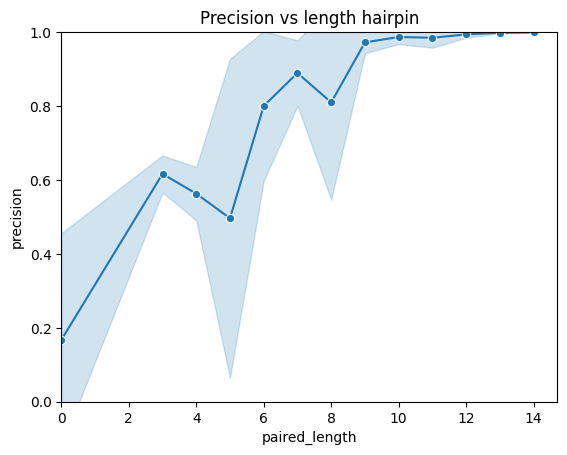

<Figure size 640x480 with 0 Axes>

In [16]:
results_df_hairpin = pd.DataFrame(results)

sns.lineplot(
    data=results_df_hairpin.sort_values("paired_length"),
    x="paired_length",
    y="precision",
    marker="o",
    errorbar="sd"
)

plt.axvline(x=0, linestyle="--")
plt.xlim(left=0)
plt.ylim(0,1)
plt.title("Precision vs length hairpin")
plt.show()


plt.savefig("precision_hairpin_20k.png", dpi=300, bbox_inches='tight')


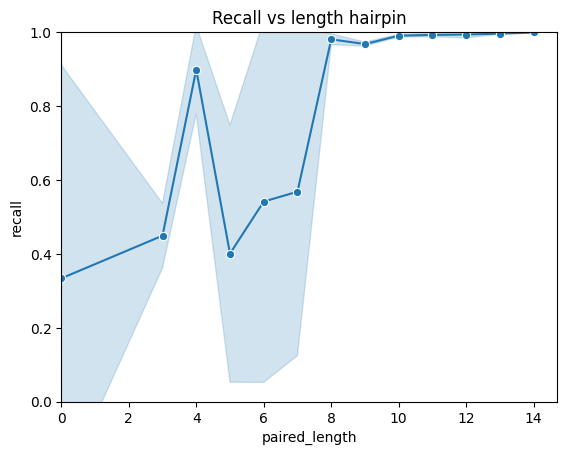

<Figure size 640x480 with 0 Axes>

In [17]:
results_df_hairpin = pd.DataFrame(results)

sns.lineplot(
    data=results_df_hairpin.sort_values("paired_length"),
    x="paired_length",
    y="recall",
    marker="o",
        errorbar="sd"
)

plt.axvline(x=0, linestyle="--")
plt.xlim(left=0)
plt.ylim(0,1)
plt.title("Recall vs length hairpin")
plt.show()

plt.savefig("recall_hairpin_20k.png", dpi=300, bbox_inches='tight')



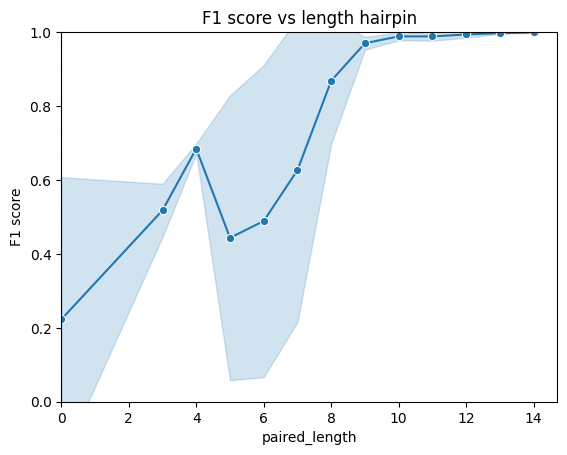

<Figure size 640x480 with 0 Axes>

In [18]:
results_df_hairpin = pd.DataFrame(results)

sns.lineplot(
    data=results_df_hairpin.sort_values("paired_length"),
    x="paired_length",
    y="F1 score",
    marker="o",
    errorbar="sd"
)

plt.axvline(x=0, linestyle="--")
plt.xlim(left=0)
plt.ylim(0,1)
plt.title("F1 score vs length hairpin")
plt.show()

plt.savefig("f1_hairpin_20k.png", dpi=300, bbox_inches='tight')



In [19]:
n_per_motif = 10000

n_total_positive = len(simple_bulgeloop) * n_per_motif

# M1: 1000 negatives
data_M3 = []

for _ in range(n_total_positive):
    seq = "".join(np.random.choice(chars, size=500, replace=True))
    data_M3.append(seq)

M3 = pd.DataFrame(data_M3, columns=["sequence"])
M3["label"] = 0

M4_base = M1.copy()
M4_base["sequence"] = M4_base["sequence"].apply(shuffle_sequence)

new_sequences = []
motifs = []
motif_starts = []

row_idx = 0

for motif in simple_bulgeloop:
    for _ in range(n_per_motif):
        background = M4_base.iloc[row_idx]["sequence"]

        new_seq, idx = insert_motif(background, motif)

        new_sequences.append(new_seq)
        motifs.append(motif)
        motif_starts.append(idx)

        row_idx += 1

M4 = pd.DataFrame({
    "sequence": new_sequences,
    "label": 1,
    "motif": motifs,
    "motif_start": motif_starts
})

M5 = pd.concat([M3, M4], ignore_index=True)

print(M5["label"].value_counts())
print(M4["motif"].value_counts())
print(M5[1000:])

label
0    130000
1    130000
Name: count, dtype: int64
motif
                                                    10000
...((..(...)))...                                   10000
...((..((...))))...                                 10000
...(((..((...)))))...                               10000
...(((..(((...))))))...                             10000
...((((...(((....)))))))...                         10000
...((((...((((....))))))))...                       10000
...(((((...((((....)))))))))...                     10000
...(((((....(((((.....))))))))))...                 10000
...((((((.....(((((.......)))))))))))...            10000
...((((((......((((((........))))))))))))...        10000
...(((((((......((((((........)))))))))))))...      10000
...(((((((......(((((((........))))))))))))))...    10000
Name: count, dtype: int64
                                                 sequence  label  \
1000    ))())(..)).()()(.(().)...)...).)....()).(.))))...      0   
1001    (.)..)(.).(..(

In [20]:
M5["encoded_sequence"] = M5["sequence"].apply(one_hot_encode, fixlength=500)

X = np.array(list(M5["encoded_sequence"].values))
y = np.array(M5["label"].values)

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=5,
    overwrite=True,
    directory="tuner_results",
    project_name="bulgeloop_global_tuning"
)

tuner.search(
    X_train_all,
    y_train_all,
    epochs=5,
    validation_split=0.2
)

best_hp_bulge = tuner.get_best_hyperparameters(1)[0]

print("Best hyperparameters:")
print(best_hp_bulge.values)

Trial 5 Complete [00h 01m 14s]
val_loss: 0.6932323575019836

Best val_loss So Far: 0.14847297966480255
Total elapsed time: 00h 07m 26s
Best hyperparameters:
{'filter_1': 16, 'kernel_1': 3, 'pool_size_1': 4, 'filter_2': 32, 'kernel_2': 3, 'pool_size_2': 4, 'units_1': 128, 'rate': 0.3, 'units_2': 1, 'learning_rate': 0.0001}


In [21]:
model_bulge = build_model(best_hp_bulge)

In [22]:
results_bulge = []

for motif in simple_bulgeloop:
    for seed in range(3):
        M_pos_bulge = M5[(M5["label"] == 1) & (M5["motif"] == motif)]

        M_neg_bulge = M5[M5["label"] == 0].sample(
            n=len(M_pos_bulge),
            random_state=seed
        )
        print("Motif:", motif)
        print("Positive contains motif:", M_pos_bulge["sequence"].str.contains(motif, regex=False).mean())
        print("Negative contains motif:", M_neg_bulge["sequence"].str.contains(motif, regex=False).mean())

        M_sub_bulge = pd.concat([M_neg_bulge, M_pos_bulge], ignore_index=False)
        M_sub_bulge["encoded_sequence"] = M_sub_bulge["sequence"].apply(one_hot_encode, fixlength=500)
        
        X = np.array(list(M_sub_bulge["encoded_sequence"].values))
        y = np.array(M_sub_bulge["label"].values)

        print(motif)
        print(M_sub_bulge["label"].value_counts())

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=seed,
            stratify=y
        )
        

        model_bulge = tuner.hypermodel.build(best_hp_bulge)


        model_bulge.fit(
            X_train,
            y_train,
            epochs=5,
            batch_size=32,
            validation_split=0.2,
            verbose=0
        )

        loss, accuracy = model_bulge.evaluate(X_test, y_test, verbose=0)

        y_pred_prob = model_bulge.predict(X_test, verbose=0)
        y_pred = (y_pred_prob >= 0.5).astype(int).ravel()
            
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        results_bulge.append({
            "motif": motif,
            "seed": seed,
            "accuracy": accuracy,
            # "best_hp": best_hp.values,
            "paired_length": paired_length(motif),
            "sequence_length": len(motif),
            "precision": precision,
            "recall": recall,
            "F1 score": f1
        })

        print(f"\nMotif: {motif}")
        print(f"Accuracy: {accuracy}")
        print(f"paired_length: {paired_length(motif)}"),
        # print(f"Best hyperparameter values: {best_hp.values}")
        print(f"Precision: {precision}")
        print(f"Recall: {recall}"),
        print(f"F1-score: {f1}")
        
with open("cnn_testdata_output_bulge_20k.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerows(results_bulge) 
        
        

Motif: 
Positive contains motif: 1.0
Negative contains motif: 1.0



label
0    10000
1    10000
Name: count, dtype: int64


/home/kelia/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Motif: 
Accuracy: 0.49549999833106995
paired_length: 0
Precision: 0.49713375796178344
Recall: 0.7805
F1-score: 0.6073929961089494
Motif: 
Positive contains motif: 1.0
Negative contains motif: 1.0



label
0    10000
1    10000
Name: count, dtype: int64


...

/home/kelia/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Motif: ...(((((((......(((((((........))))))))))))))...
Accuracy: 0.9984999895095825
paired_length: 14
Precision: 0.9975049900199601
Recall: 0.9995
F1-score: 0.9985014985014985
Motif: ...(((((((......(((((((........))))))))))))))...
Positive contains motif: 1.0
Negative contains motif: 0.0


...(((((((......(((((((........))))))))))))))...
label
0    10000
1    10000
Name: count, dtype: int64


/home/kelia/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Motif: ...(((((((......(((((((........))))))))))))))...
Accuracy: 0.9907500147819519
paired_length: 14
Precision: 0.9866137828458106
Recall: 0.995
F1-score: 0.990789146128952


In [23]:
print(M_sub_bulge["label"].value_counts())

label
0    10000
1    10000
Name: count, dtype: int64


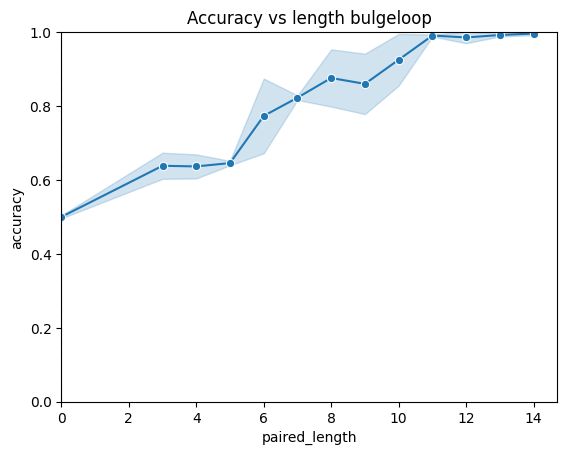

<Figure size 640x480 with 0 Axes>

In [24]:
results_df_bulge = pd.DataFrame(results_bulge)

sns.lineplot(
    data=results_df_bulge.sort_values("paired_length"),
    x="paired_length",
    y="accuracy",
    marker="o",
    errorbar="sd"
)

plt.axvline(x=0, linestyle="--")
plt.xlim(left=0)
plt.ylim(0,1)
plt.title("Accuracy vs length bulgeloop")
plt.show()

plt.savefig("accuracy_bulge_20k.png", dpi=300, bbox_inches='tight')


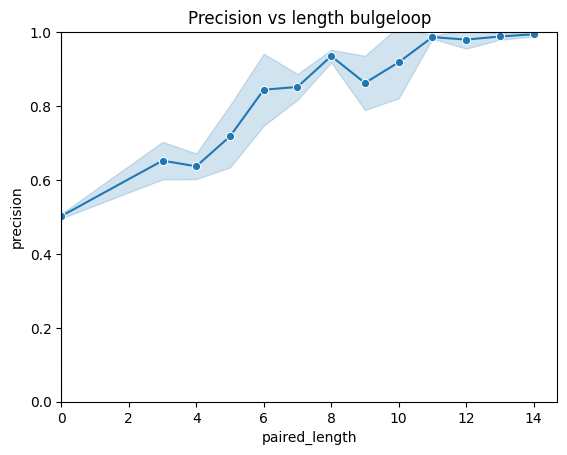

<Figure size 640x480 with 0 Axes>

In [25]:
results_df_bulge = pd.DataFrame(results_bulge)

sns.lineplot(
    data=results_df_bulge.sort_values("paired_length"),
    x="paired_length",
    y="precision",
    marker="o",
    errorbar="sd"
)

plt.axvline(x=0, linestyle="--")
plt.xlim(left=0)
plt.ylim(0,1)
plt.title("Precision vs length bulgeloop")
plt.show()

plt.savefig("precision_bulge_20k.png", dpi=300, bbox_inches='tight')


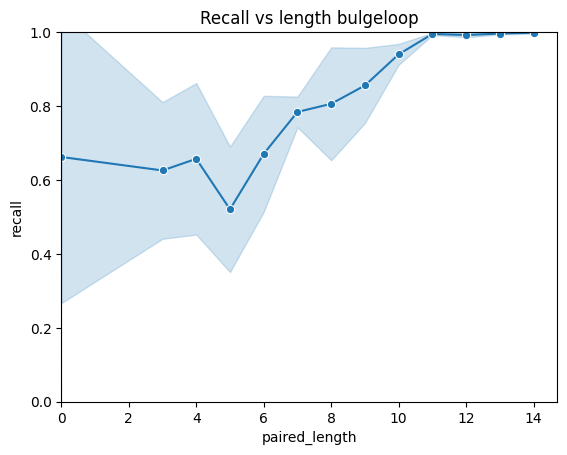

<Figure size 640x480 with 0 Axes>

In [26]:
results_df_bulge = pd.DataFrame(results_bulge)

sns.lineplot(
    data=results_df_bulge.sort_values("paired_length"),
    x="paired_length",
    y="recall",
    marker="o",
    errorbar="sd"
)

plt.axvline(x=0, linestyle="--")
plt.xlim(left=0)
plt.ylim(0,1)
plt.title("Recall vs length bulgeloop")
plt.show()


plt.savefig("recall_bulge_20k.png", dpi=300, bbox_inches='tight')



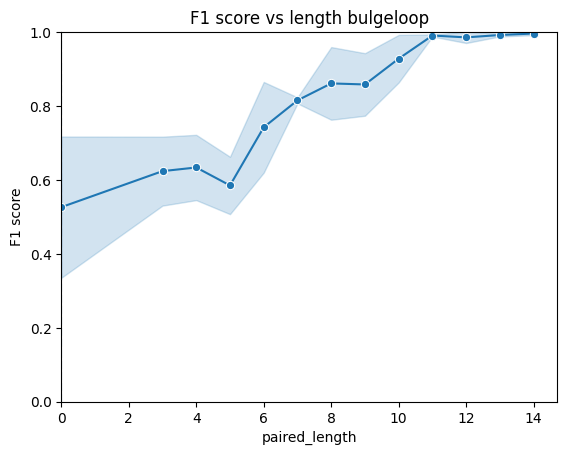

<Figure size 640x480 with 0 Axes>

In [27]:
results_df_bulge = pd.DataFrame(results_bulge)

sns.lineplot(
    data=results_df_bulge.sort_values("paired_length"),
    x="paired_length",
    y="F1 score",
    marker="o",
    errorbar="sd"
)

plt.axvline(x=0, linestyle="--")
plt.xlim(left=0)
plt.ylim(0,1)
plt.title("F1 score vs length bulgeloop")
plt.show()

plt.savefig("f1_bulge_20k.png", dpi=300, bbox_inches='tight')



In [28]:
n_per_motif = 10000

n_total_positive = len(repetitive_short_hairpins) * n_per_motif

# M1: 1000 negatives
data_M6 = []

for _ in range(n_total_positive):
    seq = "".join(np.random.choice(chars, size=500, replace=True))
    data_M6.append(seq)

M6 = pd.DataFrame(data_M6, columns=["sequence"])
M6["label"] = 0

M7_base = M1.copy()
M7_base["sequence"] = M7_base["sequence"].apply(shuffle_sequence)

new_sequences = []
motifs = []
motif_starts = []

row_idx = 0

for motif in repetitive_short_hairpins:
    for _ in range(n_per_motif):
        background = M7_base.iloc[row_idx]["sequence"]

        new_seq, idx = insert_motif(background, motif)

        new_sequences.append(new_seq)
        motifs.append(motif)
        motif_starts.append(idx)

        row_idx += 1

M7 = pd.DataFrame({
    "sequence": new_sequences,
    "label": 1,
    "motif": motifs,
    "motif_start": motif_starts
})

M8 = pd.concat([M6, M7], ignore_index=True)

print(M8["label"].value_counts())
print(M7["motif"].value_counts())
print(M8[1000:])

label
0    130000
1    130000
Name: count, dtype: int64
motif
                                                                                                                                                       10000
...(((...)))...                                                                                                                                        10000
...(((...)))...(((...)))...                                                                                                                            10000
...(((...)))...(((...)))...(((...)))...                                                                                                                10000
...(((...)))...(((...)))...(((...)))...(((...)))...                                                                                                    10000
...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...                                                                                        10

In [29]:
M8["encoded_sequence"] = M8["sequence"].apply(one_hot_encode, fixlength=500)

X = np.array(list(M8["encoded_sequence"].values))
y = np.array(M8["label"].values)

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=5,
    overwrite=True,
    directory="tuner_results",
    project_name="repetitive_hairpin_global_tuning"
)

tuner.search(
    X_train_all,
    y_train_all,
    epochs=5,
    validation_split=0.2
)

best_hp_repetitive = tuner.get_best_hyperparameters(1)[0]

print("Best hyperparameters:")
print(best_hp_repetitive.values)

Trial 5 Complete [00h 01m 23s]
val_loss: 0.13928595185279846

Best val_loss So Far: 0.13912540674209595
Total elapsed time: 00h 07m 19s
Best hyperparameters:
{'filter_1': 128, 'kernel_1': 5, 'pool_size_1': 3, 'filter_2': 16, 'kernel_2': 5, 'pool_size_2': 4, 'units_1': 32, 'rate': 0.3, 'units_2': 1, 'learning_rate': 0.001}


In [30]:
model_repetitive = build_model(best_hp_repetitive)

In [31]:
results_repetitive = []

for motif in repetitive_short_hairpins:
    for seed in range(3):
        M_pos_repetitive = M8[(M8["label"] == 1) & (M8["motif"] == motif)]

        M_neg_repetitive = M8[M8["label"] == 0].sample(
            n=len(M_pos_repetitive),
            random_state=seed
        )
        print("Motif:", motif)
        print("Positive contains motif:", M_pos_repetitive["sequence"].str.contains(motif, regex=False).mean())
        print("Negative contains motif:", M_neg_repetitive["sequence"].str.contains(motif, regex=False).mean())

        M_sub_repetitive = pd.concat([M_neg_repetitive, M_pos_repetitive], ignore_index=False)
        M_sub_repetitive["encoded_sequence"] = M_sub_repetitive["sequence"].apply(one_hot_encode, fixlength=500)
        
        X = np.array(list(M_sub_repetitive["encoded_sequence"].values))
        y = np.array(M_sub_repetitive["label"].values)

        print(motif)
        print(M_sub_repetitive["label"].value_counts())

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=seed,
            stratify=y
        )
        

        model_repetitive = tuner.hypermodel.build(best_hp_bulge)


        model_repetitive.fit(
            X_train,
            y_train,
            epochs=5,
            batch_size=32,
            validation_split=0.2,
            verbose=0
        )

        loss, accuracy = model_repetitive.evaluate(X_test, y_test, verbose=0)

        y_pred_prob = model_repetitive.predict(X_test, verbose=0)
        y_pred = (y_pred_prob >= 0.5).astype(int).ravel()
            
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        results_repetitive.append({
            "motif": motif,
            "seed": seed,
            "accuracy": accuracy,
            # "best_hp": best_hp.values,
            "repetitive_count": repetitive_count(motif),
            "paired_length": paired_length(motif),
            "sequence_length": len(motif),
            "precision": precision,
            "recall": recall,
            "F1 score": f1,
        })

        print(f"\nMotif: {motif}")
        print(f"Accuracy: {accuracy}")
        print(f"paired_length: {paired_length(motif)}")
        print(f"repetitive_count:{repetitive_count(motif)}")
        # print(f"Best hyperparameter values: {best_hp.values}")
        print(f"Precision: {precision}")
        print(f"Recall: {recall}")
        print(f"F1-score: {f1}")
        
with open("cnn_testdata_output_repetitive_20k.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerows(results_repetitive) 

Motif: 
Positive contains motif: 1.0
Negative contains motif: 1.0



label
0    10000
1    10000
Name: count, dtype: int64


/home/kelia/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Motif: 
Accuracy: 0.5024999976158142
paired_length: 0
repetitive_count:0
Precision: 0.5409836065573771
Recall: 0.033
F1-score: 0.06220546654099906
Motif: 
Positive contains motif: 1.0
Negative contains motif: 1.0



label
0    10000
1    10000
Name: count, dtype: int64


...

/home/kelia/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Motif: ...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...
Accuracy: 1.0
paired_length: 36
repetitive_count:12
Precision: 1.0
Recall: 1.0
F1-score: 1.0
Motif: ...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...
Positive contains motif: 1.0
Negative contains motif: 0.0


...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...
label
0    10000
1    10000
Name: count, dtype: int64


/home/kelia/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Motif: ...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...(((...)))...
Accuracy: 1.0
paired_length: 36
repetitive_count:12
Precision: 1.0
Recall: 1.0
F1-score: 1.0


In [32]:
print(M_sub_repetitive["label"].value_counts())

label
0    10000
1    10000
Name: count, dtype: int64


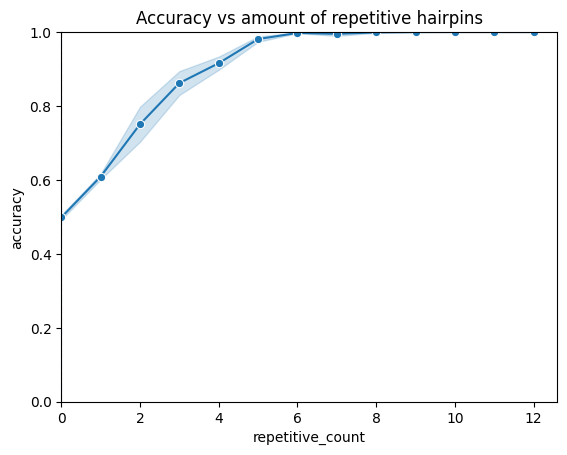

<Figure size 640x480 with 0 Axes>

In [33]:
results_df_repetitive = pd.DataFrame(results_repetitive)

sns.lineplot(
    data=results_df_repetitive.sort_values("paired_length"),
    x="repetitive_count",
    y="accuracy",
    marker="o",
    errorbar="sd"
)

plt.axvline(x=0, linestyle="--")
plt.xlim(left=0)
plt.ylim(0,1)
plt.title("Accuracy vs amount of repetitive hairpins")
plt.show()


plt.savefig("accuracy_repetitive_20k.png", dpi=300, bbox_inches='tight')



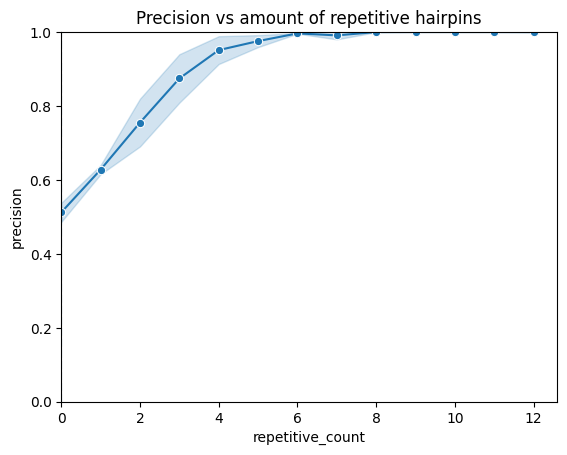

<Figure size 640x480 with 0 Axes>

In [34]:
results_df_repetitive = pd.DataFrame(results_repetitive)

sns.lineplot(
    data=results_df_repetitive.sort_values("paired_length"),
    x="repetitive_count",
    y="precision",
    marker="o",
    errorbar="sd"
)

plt.axvline(x=0, linestyle="--")
plt.xlim(left=0)
plt.ylim(0,1)
plt.title("Precision vs amount of repetitive hairpins")
plt.show()

plt.savefig("precision_repetitive_20k.png", dpi=300, bbox_inches='tight')



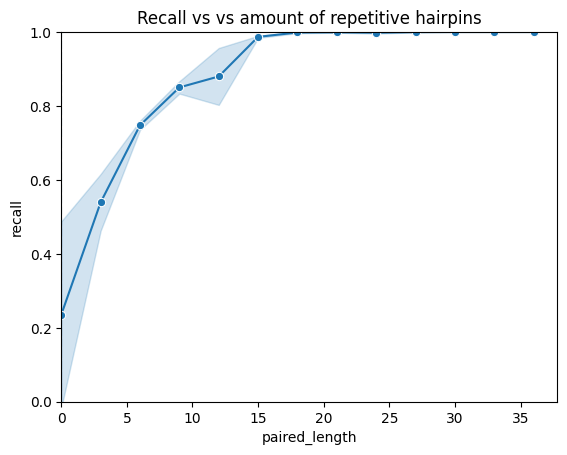

<Figure size 640x480 with 0 Axes>

In [35]:
results_df_repetitive = pd.DataFrame(results_repetitive)

sns.lineplot(
    data=results_df_repetitive.sort_values("paired_length"),
    x="paired_length",
    y="recall",
    marker="o",
    errorbar="sd"
)

plt.axvline(x=0, linestyle="--")
plt.xlim(left=0)
plt.ylim(0,1)
plt.title("Recall vs vs amount of repetitive hairpins")
plt.show()

plt.savefig("recall_repetitive_20k.png", dpi=300, bbox_inches='tight')



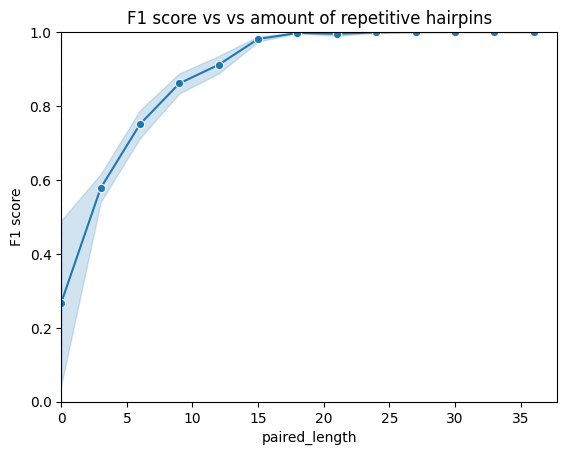

<Figure size 640x480 with 0 Axes>

In [36]:
results_df_repetitive = pd.DataFrame(results_repetitive)

sns.lineplot(
    data=results_df_repetitive.sort_values("paired_length"),
    x="paired_length",
    y="F1 score",
    marker="o",
    errorbar="sd"
)

plt.axvline(x=0, linestyle="--")
plt.xlim(left=0)
plt.ylim(0,1)
plt.title("F1 score vs vs amount of repetitive hairpins")
plt.show()

plt.savefig("f1_repetitive_20k.png", dpi=300, bbox_inches='tight')

